# animations

In [7]:
using JLD2
using Plots

gr()
default(size=(900, 500), linewidth=2)

const ROOT = normpath(joinpath(@__DIR__, ".."))
mkpath(joinpath(ROOT, "data/generated/animations"))

const SITES = ["lat30lon-50", "lat-25lon-10", "lat-45lon80", "lat0lon-140", "lat30lon-150", "lat40lon-25"]

function load_v2(site)
    qt_file = joinpath(ROOT, "output/era5/ml_forced_30day_v2_qt_$(site).jld2")
    gly_file = site == "lat30lon-50" ?
        joinpath(ROOT, "data/generated/glorys_processed.jld2") :
        joinpath(ROOT, "data/generated/glorys_processed_$(site).jld2")
    (sim = isfile(qt_file) ? JLD2.load(qt_file) : nothing,
     gly = isfile(gly_file) ? JLD2.load(gly_file) : nothing)
end

load_v2 (generic function with 1 method)

## T profile day by day

In [8]:
function animate_T_profile(site::String; fps=4)
    d = load_v2(site)
    sim, gly = d.sim, d.gly
    sim === nothing && (println("no sim for $site"); return)

    vert_res = length(sim["T_profiles"][1])
    z = collect(range(0, stop=100, length=vert_res))

    N = min(length(sim["T_profiles"]), gly === nothing ? 31 : length(gly["T_profiles"]))

    # axis limits
    allT_sim = reduce(vcat, sim["T_profiles"][1:N])
    allT_gly = gly === nothing ? allT_sim : reduce(vcat, gly["T_profiles"][1:N])
    xlim = (minimum(vcat(allT_sim, allT_gly)) - 0.2, maximum(vcat(allT_sim, allT_gly)) + 0.2)

    anim = @animate for i in 1:N
        day = round(sim["saved_times"][i] / 86400, digits=1)
        p = plot(reverse(sim["T_profiles"][i]), z,
                 label="sim v2 QT", color=:red, lw=2,
                 xlabel="Temperature (°C)", ylabel="Depth (m)",
                 title="$site — day $day", xlim=xlim, yflip=true, legend=:bottomright)
        if gly !== nothing && i <= length(gly["T_profiles"])
            plot!(p, gly["T_profiles"][i], z, label="GLORYS", color=:green, lw=2, linestyle=:dash)
        end
        p
    end
    out = joinpath(ROOT, "data/generated/animations/T_profile_$(site).gif")
    gif(anim, out, fps=fps)
    println("saved $out")
end

animate_T_profile (generic function with 1 method)

In [9]:
animate_T_profile("lat30lon-50")

saved c:\Users\jakec\ocean-ml-closure\data/generated/animations/T_profile_lat30lon-50.gif


┌ Info: Saved animation to c:\Users\jakec\ocean-ml-closure\data\generated\animations\T_profile_lat30lon-50.gif
└ @ Plots C:\Users\jakec\.julia\packages\Plots\GIume\src\animation.jl:156


## hovmoller heatmaps

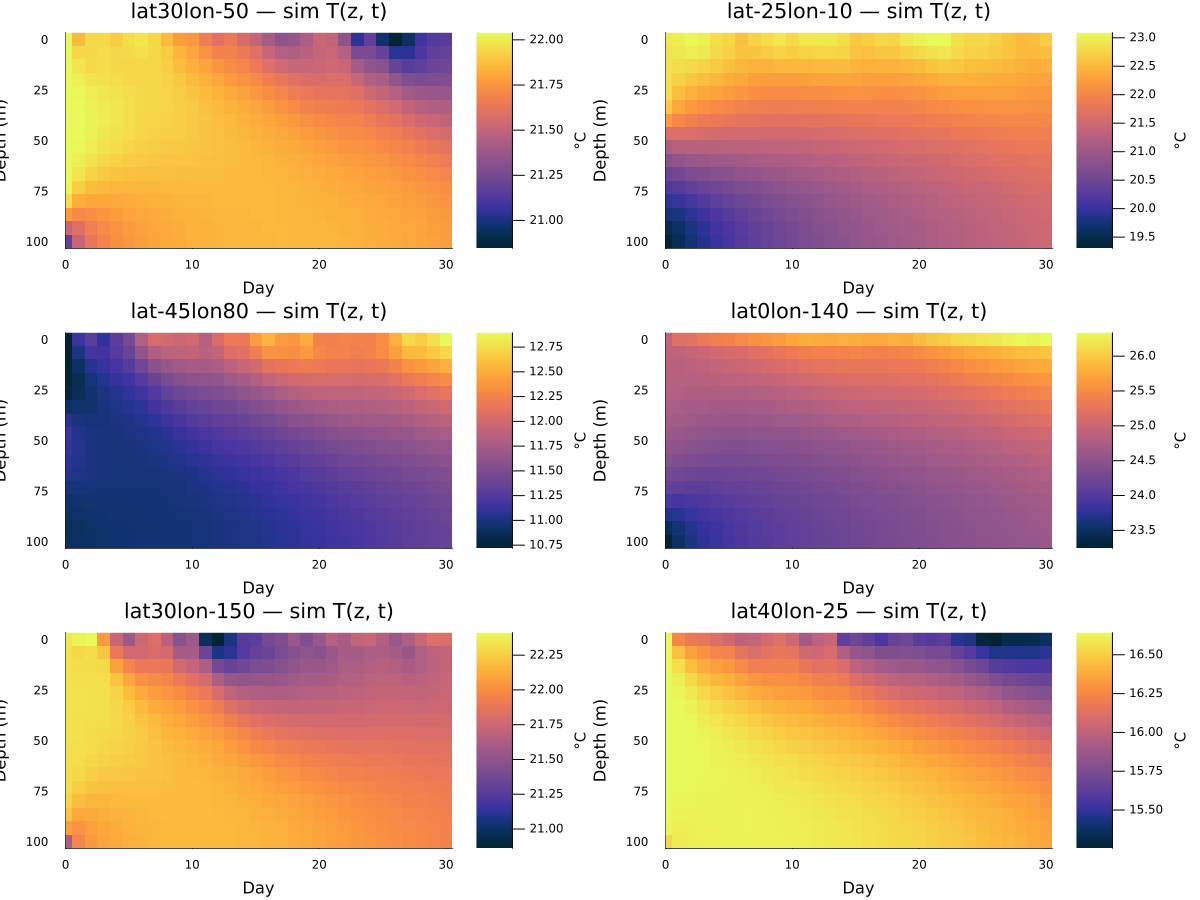

In [10]:
function hovmoller_T(site::String; which=:v2)
    d = load_v2(site)
    sim = d.sim
    sim === nothing && return nothing
    T = reduce(hcat, [reverse(p) for p in sim["T_profiles"]])   # rows = depth (surface top), cols = time
    t = sim["saved_times"] ./ 86400
    z = collect(range(0, stop=100, length=size(T, 1)))
    heatmap(t, z, T,
            xlabel="Day", ylabel="Depth (m)",
            title="$site — sim T(z, t)", yflip=true, c=:thermal, colorbar_title="°C")
end

plot([hovmoller_T(s) for s in SITES if load_v2(s).sim !== nothing]...,
     layout=(3,2), size=(1200, 900))

## all 6 sites surface T animated

In [11]:
function animate_all_sites_surface_T(; fps=4)
    data = Dict(s => load_v2(s) for s in SITES)
    N = 31
    anim = @animate for day in 0:N-1
        panels = Plots.Plot[]
        for s in SITES
            d = data[s]
            p = plot(title=s, xlabel="Day", ylabel="Surface T", legend=:topright, titlefontsize=10)
            if d.sim !== nothing
                t = d.sim["saved_times"] ./ 86400
                y = [pr[end] for pr in d.sim["T_profiles"]]
                keep = t .<= day
                plot!(p, t[keep], y[keep], label="sim v2", color=:red, lw=1.5)
            end
            if d.gly !== nothing
                y = [pr[1] for pr in d.gly["T_profiles"][1:min(day+1, length(d.gly["T_profiles"]))]]
                plot!(p, 0:length(y)-1, y, label="GLORYS", color=:green, lw=1.5, linestyle=:dash)
            end
            push!(panels, p)
        end
        plot(panels..., layout=(3,2), size=(1200, 900), plot_title="Day $day")
    end
    out = joinpath(ROOT, "data/generated/animations/all_sites_surface_T.gif")
    gif(anim, out, fps=fps)
    println("saved $out")
end

animate_all_sites_surface_T (generic function with 1 method)

In [12]:
animate_all_sites_surface_T()

saved c:\Users\jakec\ocean-ml-closure\data/generated/animations/all_sites_surface_T.gif


┌ Info: Saved animation to c:\Users\jakec\ocean-ml-closure\data\generated\animations\all_sites_surface_T.gif
└ @ Plots C:\Users\jakec\.julia\packages\Plots\GIume\src\animation.jl:156
